In [1]:
import pandas as pd
import openpyxl
import os
import glob, re
import matplotlib.pyplot as plt
import functions as f

In [2]:
path = "model_Fe_Si_B_260311/**/test_res/*_test.xlsx"
files = glob.glob(path, recursive=True)

In [3]:
df = f.read_excel(files, 'errors')
df = df[['id', 'epochs']+[c for c in df.columns if c not in ['id', 'epochs']]]
#df

In [4]:
#voy a generar un dataframe para cada modelo
scmace = df.query('id == "scmace"')
#matpes = df.query('id == "matpes"')
matpes = df.query('id == "matpes" & epochs != [500, 150]') #esto es ahorita que no quiero ver el de 500 epochs
scmace_nofe8b4 = df.query('id == "scmace_nofe8b4"')
matpes_nofe8b4 = df.query('id == "matpes_nofe8b4"')

MAE and RMSE for energy

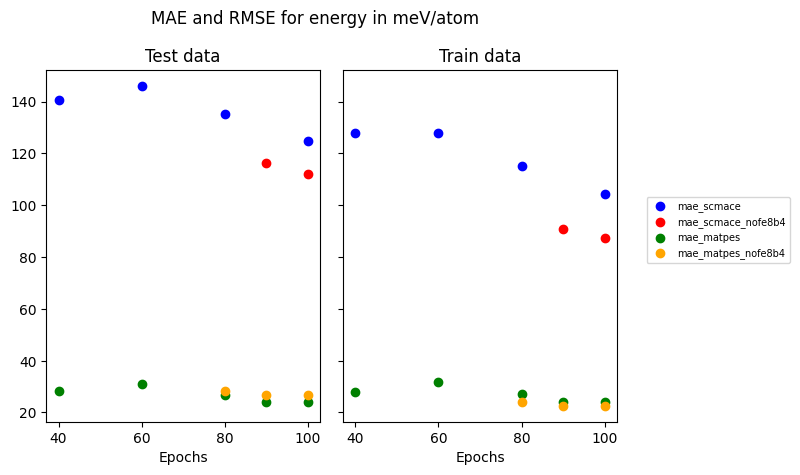

In [5]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

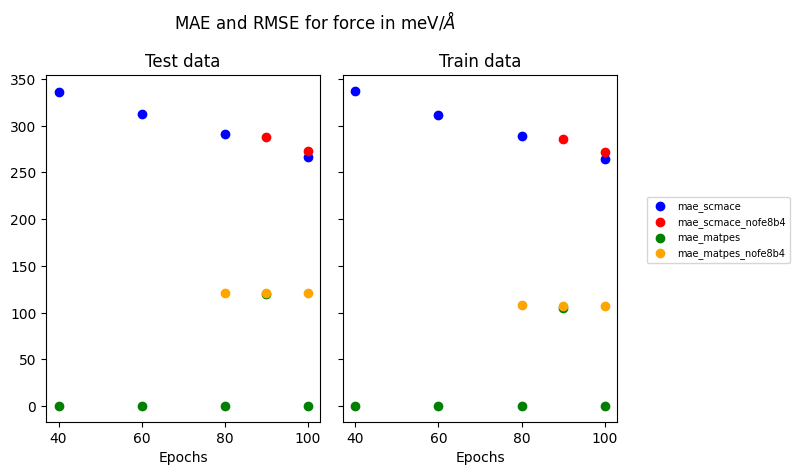

In [6]:
f.plot_global_error([scmace, scmace_nofe8b4, matpes, matpes_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4', 'matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'force')

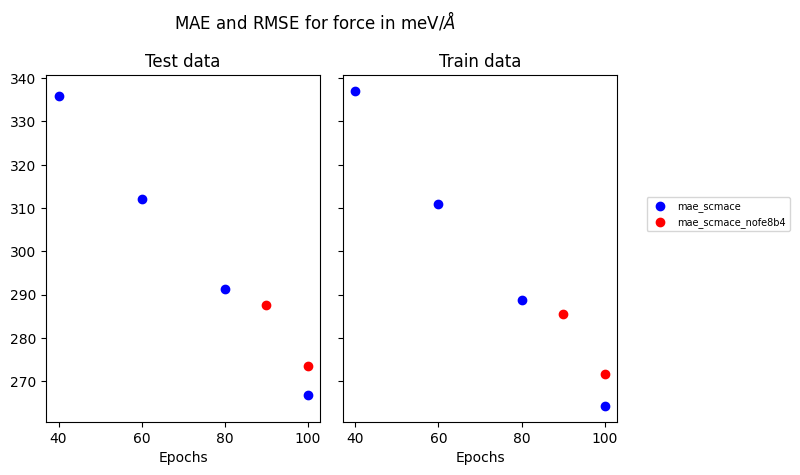

In [7]:
f.plot_global_error([scmace, scmace_nofe8b4], ['mae'], ['scmace', 'scmace_nofe8b4'], ['Test data', 'Train data'], 'force')

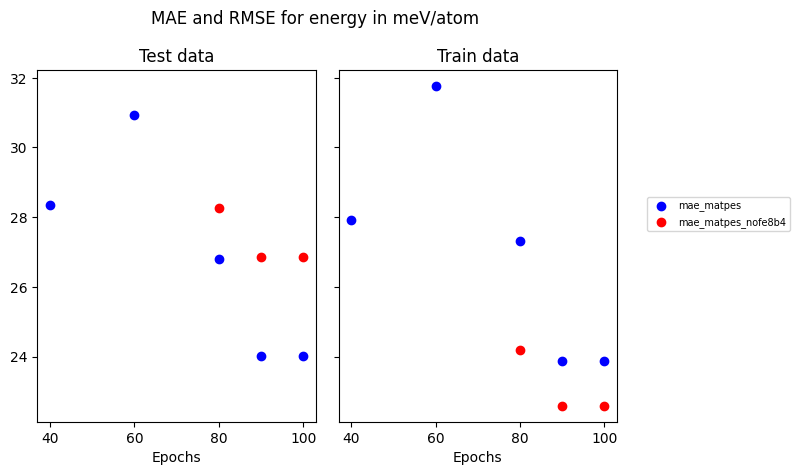

In [8]:
f.plot_global_error([matpes, matpes_nofe8b4], ['mae'], ['matpes', 'matpes_nofe8b4'], ['Test data', 'Train data'], 'energy')

In [9]:
#matpes.query('error == ["test_energy"]').sort_values('epochs', ascending=True)

In [10]:
print(f.min(scmace, 'mae'), f.min(matpes, 'mae'))

                                                model         mae
error                                                            
test_energy   model_rnd_e_scmace_lr0.0001_100_10_test  124.774518
test_force    model_rnd_e_scmace_lr0.0001_100_10_test  266.765534
train_energy  model_rnd_e_scmace_lr0.0001_100_10_test  104.387671
train_force   model_rnd_e_scmace_lr0.0001_100_10_test  264.249749                                                 model        mae
error                                                           
test_energy   model_rnd_e_matpes_lr0.0001_100_10_test  24.019415
test_force    model_rnd_e_matpes_lr0.0001_100_10_test   0.119892
train_energy  model_rnd_e_matpes_lr0.0001_100_10_test  23.863738
train_force   model_rnd_e_matpes_lr0.0001_100_10_test   0.105124


Reading the config errors

In [11]:
df_config =f.read_excel(files, 'config_errors')
df_config = df_config[['id', 'epochs', 'config', 'n_configs', 'mae', 'rmse', 'error', 'model']]
#df_config

In [12]:
#voy a generar un dataframe para cada modelo
scmace_config = df_config.query('id == "scmace"')
#matpes_config = df_config.query('id == "matpes"')
matpes_config = df_config.query('id == "matpes" & epochs != [500, 150]')
scmace_nofe8b4_config = df_config.query('id == "scmace_nofe8b4"')
matpes_nofe8b4_config = df_config.query('id == "matpes_nofe8b4"')

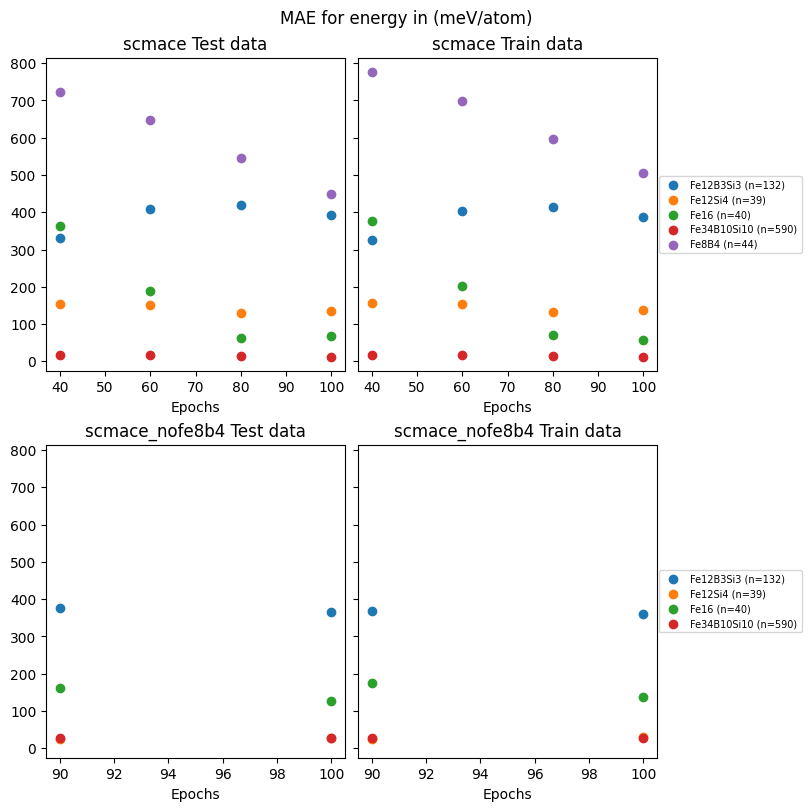

In [13]:
f.plot_config_error([scmace_config, scmace_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')

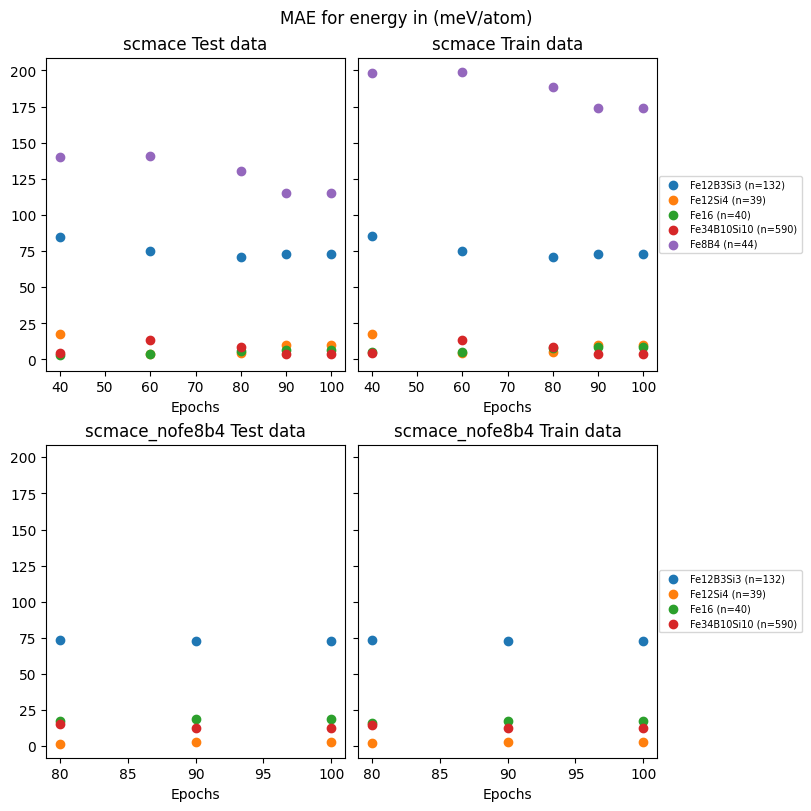

In [14]:
f.plot_config_error([matpes_config, matpes_nofe8b4_config], 'mae', ['Test data', 'Train data'], 'MAE', ['scmace', 'scmace_nofe8b4'], 'energy')